In [37]:
import pandas as pd
import numpy as np

filter_colours_lsst = {'lsstu': '#6A5ACD', 'lsstg': '#2ca02c', 'lsstr': '#d62728', 'lssti': '#ff7f0e', 'lsstz': '#8c564b', 'lssty': '#1b1b1b'}


In [14]:
generated_AGN_lc_df = pd.read_csv("../../mallorn_data/augmented_lcs/AGN_augmented_samples.csv", delimiter = ",")
generated_SN_lc_df = pd.read_csv("../../mallorn_data/augmented_lcs/SN_augmented_samples.csv", delimiter = ",")
generated_TDE_lc_df = pd.read_csv("../../mallorn_data/augmented_lcs/TDE_augmented_samples.csv", delimiter = ",")
old_generated_lc_df = pd.read_csv("../../MALLORN REDBACK/Data/samples_TDE_full_lightcurves_LLM_corrected_resampled.csv", delimiter = ",")

log_df = pd.read_csv("../../mallorn_data/train_log.csv", delimiter = ",")

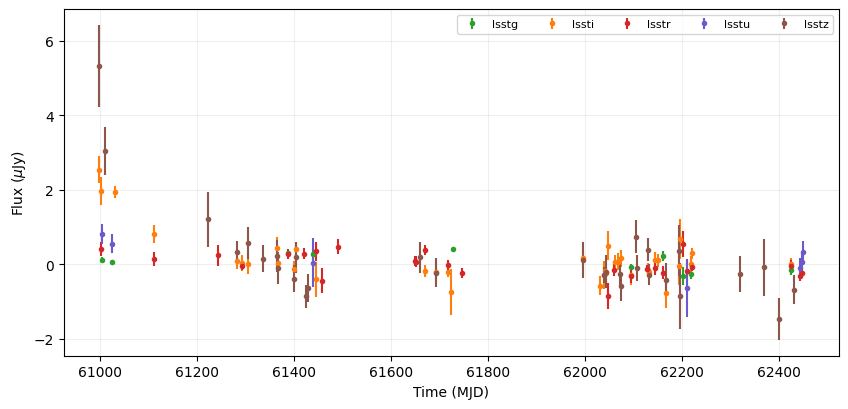

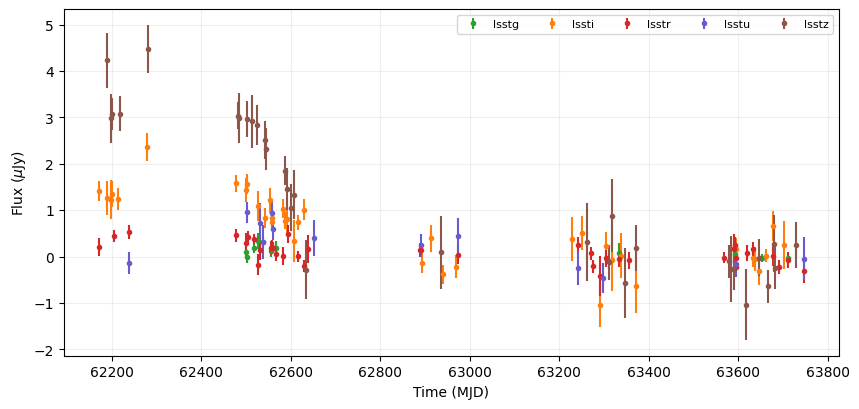

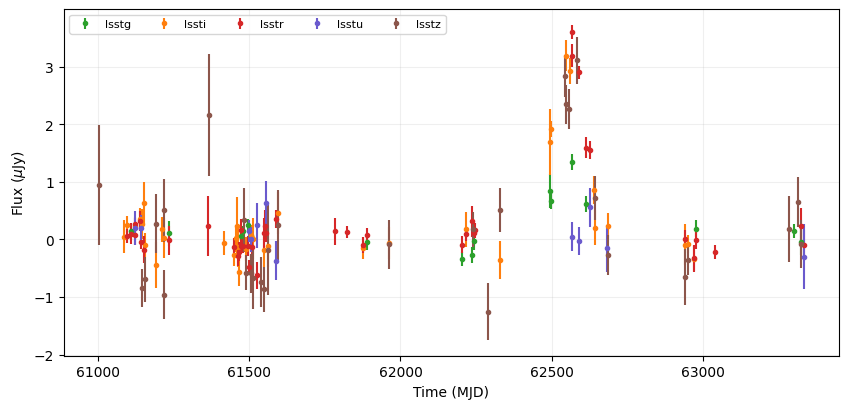

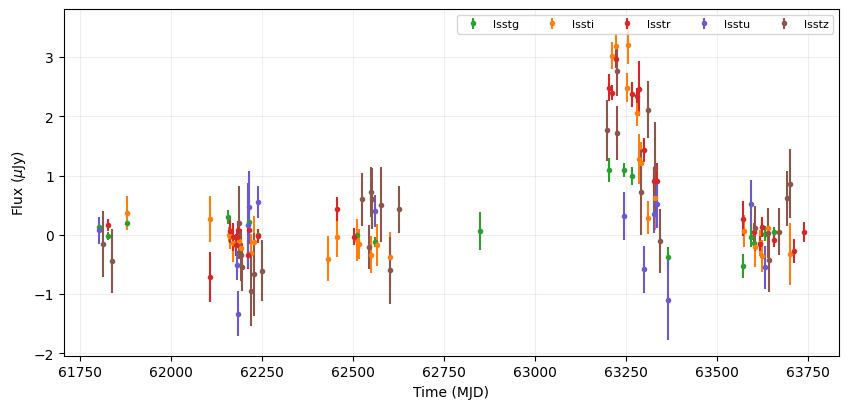

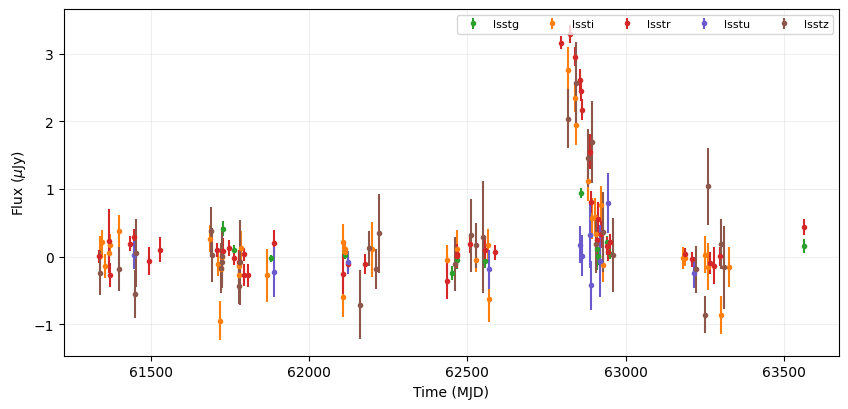

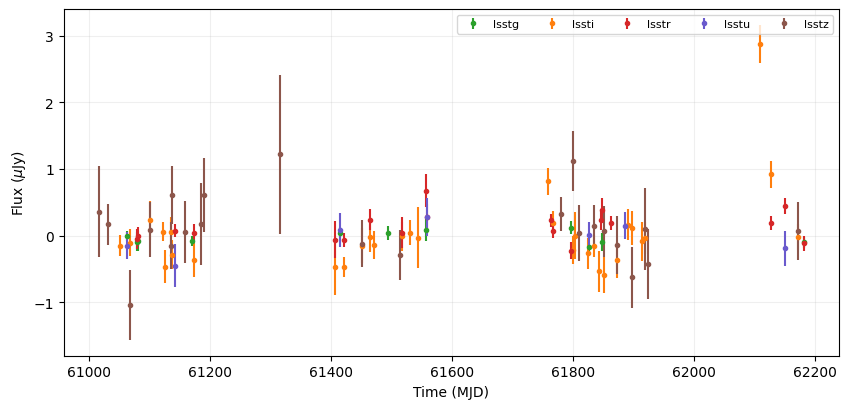

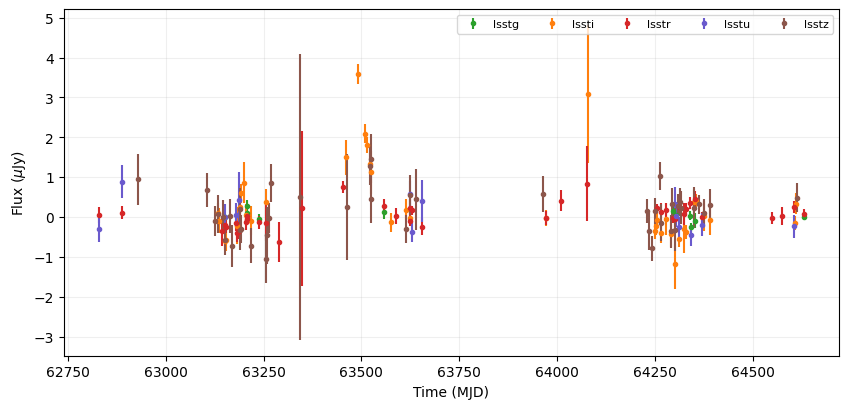

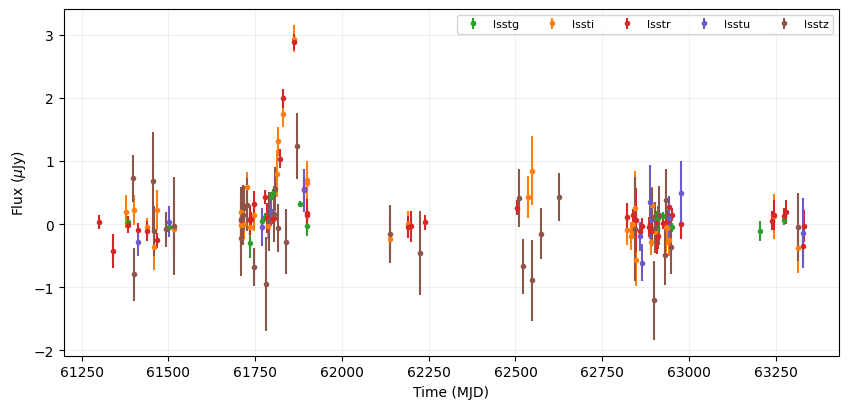

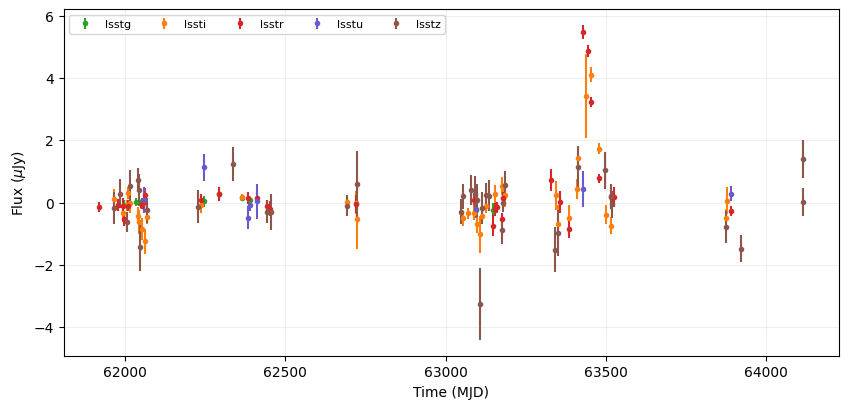

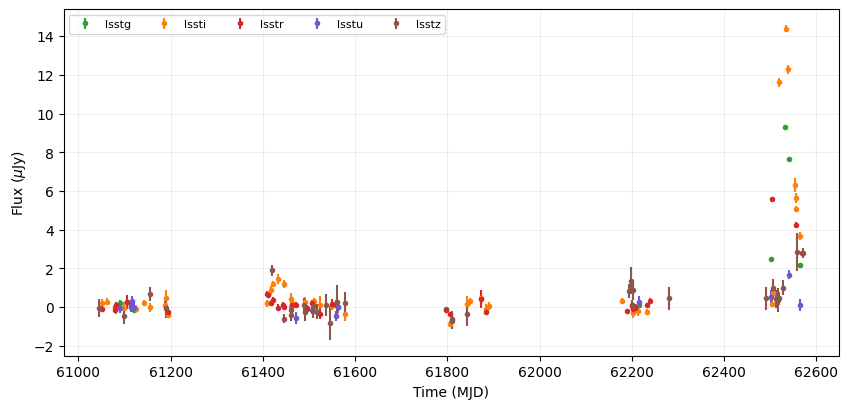

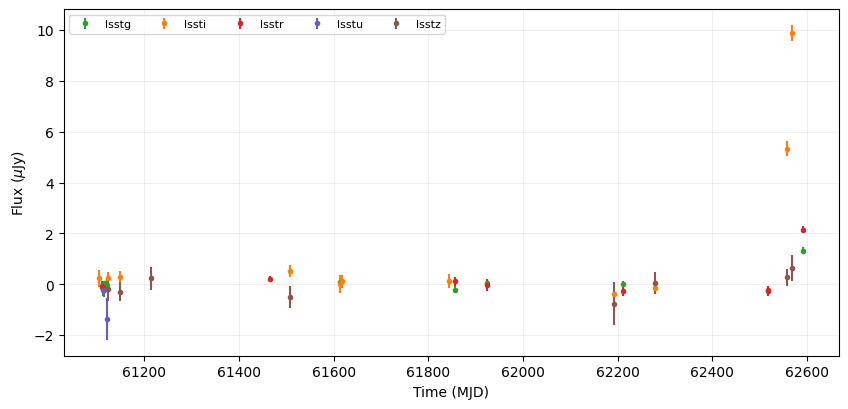

In [ ]:
for object_id in np.unique(generated_SN_lc_df["object_id"])[839:850]:

    object_lc_mask = (generated_SN_lc_df['object_id'] == object_id)
    object_lc_df = generated_SN_lc_df.loc[object_lc_mask].copy()
    object_lc_df.sort_values(by = 'Time (MJD)', inplace = True)

    import matplotlib.pyplot as plt
    import matplotlib as mpl
    mpl.rcParams.update(mpl.rcParamsDefault)

    fig, ax = plt.subplots(figsize = (10, 4.5))

    unique_bands = np.unique(object_lc_df["Filter"])

    for band_name in ["lsst" + band for band in unique_bands]:

        band_indices = object_lc_df["Filter"] == band_name[-1]
        plt.errorbar(object_lc_df["Time (MJD)"].iloc[band_indices], object_lc_df["Flux"].iloc[band_indices], yerr = object_lc_df["Flux_err"].iloc[band_indices], fmt = " ", marker = "o", ms = 3, color = filter_colours_lsst[band_name], label = band_name)

    plt.xlabel("Time (MJD)")
    plt.ylabel(r"Flux ($\mu$Jy)")
    ax.grid(True, alpha = 0.2)
    ax.legend(ncol = 6, fontsize = 8)
    plt.show()

In [24]:
original_redshift = log_df["Z"].to_numpy()
old_aug_redshift = old_generated_lc_df["Z"][np.unique(old_generated_lc_df["object_id"], return_index = True)[1]].to_numpy()
new_aug_AGN_redshift = generated_AGN_lc_df["redshift"][np.unique(generated_AGN_lc_df["object_id"], return_index = True)[1]].to_numpy()
new_aug_SN_redshift = generated_SN_lc_df["redshift"][np.unique(generated_SN_lc_df["object_id"], return_index = True)[1]].to_numpy()
new_aug_TDE_redshift = generated_TDE_lc_df["redshift"][np.unique(generated_TDE_lc_df["object_id"], return_index = True)[1]].to_numpy()

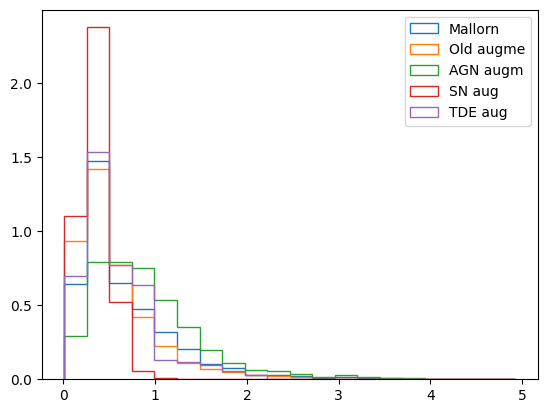

In [42]:
bins = plt.hist(original_redshift, bins = 20, histtype = "step", density = True, label = "Mallorn")
plt.hist(old_aug_redshift, bins = bins[1], histtype = "step", density = True, label = "Old augme")
plt.hist(new_aug_AGN_redshift, bins = bins[1], histtype = "step", density = True, label = "AGN augm")
plt.hist(new_aug_SN_redshift, bins = bins[1], histtype = "step", density = True, label = "SN aug")
plt.hist(new_aug_TDE_redshift, bins = bins[1], histtype = "step", density = True, label = "TDE aug")
plt.legend()
plt.show()

In [38]:
original_EBV = log_df["EBV"].to_numpy()
old_aug_EBV = old_generated_lc_df["EBV"][np.unique(old_generated_lc_df["object_id"], return_index = True)[1]].to_numpy()
new_aug_AGN_EBV = generated_AGN_lc_df["EBV"][np.unique(generated_AGN_lc_df["object_id"], return_index = True)[1]].to_numpy()
new_aug_SN_EBV = generated_SN_lc_df["EBV"][np.unique(generated_SN_lc_df["object_id"], return_index = True)[1]].to_numpy()
new_aug_TDE_EBV = generated_TDE_lc_df["EBV"][np.unique(generated_TDE_lc_df["object_id"], return_index = True)[1]].to_numpy()

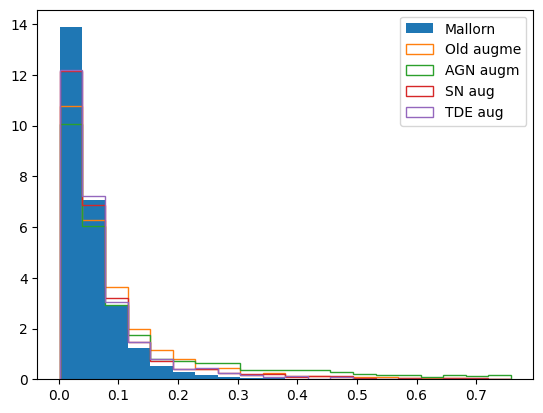

In [41]:
bins = plt.hist(original_EBV, bins = 20, density = True, label = "Mallorn")
plt.hist(old_aug_EBV, bins = bins[1], histtype = "step", density = True, label = "Old augme")
plt.hist(new_aug_AGN_EBV, bins = bins[1], histtype = "step", density = True, label = "AGN augm")
plt.hist(new_aug_SN_EBV, bins = bins[1], histtype = "step", density = True, label = "SN aug")
plt.hist(new_aug_TDE_EBV, bins = bins[1], histtype = "step", density = True, label = "TDE aug")
plt.legend()
plt.show()